In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/test-gan-competition/shard_02/data.jsonl
/kaggle/input/test-gan-competition/shard_45/data.jsonl
/kaggle/input/test-gan-competition/shard_09/data.jsonl
/kaggle/input/test-gan-competition/shard_37/data.jsonl
/kaggle/input/test-gan-competition/shard_35/data.jsonl
/kaggle/input/test-gan-competition/shard_15/data.jsonl
/kaggle/input/test-gan-competition/shard_31/data.jsonl
/kaggle/input/test-gan-competition/shard_50/data.jsonl
/kaggle/input/test-gan-competition/shard_20/data.jsonl
/kaggle/input/test-gan-competition/shard_25/data.jsonl
/kaggle/input/test-gan-competition/shard_46/data.jsonl
/kaggle/input/test-gan-competition/shard_39/data.jsonl
/kaggle/input/test-gan-competition/shard_40/data.jsonl
/kaggle/input/test-gan-competition/shard_44/data.jsonl
/kaggle/input/test-gan-competition/shard_33/data.jsonl
/kaggle/input/test-gan-competition/shard_59/data.jsonl
/kaggle/input/test-gan-competition/shard_53/data.jsonl
/kaggle/input/test-gan-competition/shard_54/data.jsonl
/kaggle/in

# **Importing Relevant Libraries**

In [3]:
import io
import os
import json
import base64
import shutil
import math
import zipfile
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.autograd as autograd
from tqdm import tqdm
import matplotlib.pyplot as plt
from torchvision import models, transforms
import numpy as np
import pandas as pd
from io import BytesIO
from scipy import linalg
from PIL import Image, ImageOps
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.utils as vutils
import torch.optim as optim
from kaggle_secrets import UserSecretsClient
from IPython.display import FileLink
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
from torchvision.models import inception_v3, Inception_V3_Weights

In [ ]:
pip install pytorch-fid

# **Hyperparameters for DC-GAN Model**

In [ ]:
# Hyperparameters
batch_size = 128
z_dim = 100  # Size of the noise vector
image_size = 32
channels = 3
epochs = 30
lr = 0.0002
beta1 = 0.5  # Adam optimizer beta1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
# Create output folder
os.makedirs("generated_images", exist_ok=True)

# **Data Pre-processing(Decoding JSONL)**

In [4]:
def decode_record(rec):
    b64 = rec.get("img64") or rec.get("image") or rec.get("img_b64")
    if b64 is None:
        print("No base64 found")
        return None
    try:
        img_bytes = base64.b64decode(b64)
        img = Image.open(io.BytesIO(img_bytes))
        img = img.convert("RGB")  # <-- force 3 channels
        img = img.resize((32, 32))  # <-- force size
        return img
    except Exception:
        print("Corrupt image, skipping.")
        return None

class KaggleImageDataset(Dataset):
    def __init__(self, jsonl_paths, transform=None):
        self.records = []
        self.transform = transform
        for path in jsonl_paths:
            with open(path, "r") as f:
                for line in f:
                    self.records.append(json.loads(line))
        print("Total records:", len(self.records))
    def __len__(self):
        return len(self.records)
    def __getitem__(self, idx):
        rec = self.records[idx]
        img = decode_record(rec)
        if img is None:
            # fallback black RGB image
            img = Image.new("RGB", (32, 32), (0,0,0))

        if self.transform:
            img = self.transform(img)
        return img

# **Transformation Pipeline(Resizing & Normalizing)**

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),                   # → (3, H, W)
    transforms.Normalize([0.5]*3, [0.5]*3)   # Normalize RGB
])

# **Dataset Loading**

In [7]:
zip_files = [
    "/kaggle/input/test-gan-competition/shard_02/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_45/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_09/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_37/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_35/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_15/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_31/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_50/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_20/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_25/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_46/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_39/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_40/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_44/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_33/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_59/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_53/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_54/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_42/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_41/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_04/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_07/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_47/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_18/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_08/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_03/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_43/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_55/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_06/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_12/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_11/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_51/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_13/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_38/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_52/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_17/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_16/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_26/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_48/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_00/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_27/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_24/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_21/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_57/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_28/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_32/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_29/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_10/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_19/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_49/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_14/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_23/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_56/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_30/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_36/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_05/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_58/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_01/data.jsonl",
    # "/kaggle/input/test-gan-competition/shard_22/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_34/data.jsonl"       
]
dataset = KaggleImageDataset(zip_files, transform)
loader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=2, drop_last=True)

Total records: 30000


In [8]:
print(dataset.records[5])  

{'id': 'train-002005', 'mode': 'RGBA', 'size': [32, 32], 'exif_rot': 270, 'invert': False, 'label': 5, 'img_b64': 'iVBORw0KGgoAAAANSUhE###', 'alpha_b64': 'iVBORw0KGgoAAAANSUhEUgAAABoAAAAdCAAAAACRJCOqAAAAcUlEQVR4nJWSSxLAIAhDM73/nV8XfgYJ0ikLBgOBoEqShCRY4QjMUEoRcbx4em+HOMaQGww9G4nhIfaq9dtqIupu4H/vp7tM7bXJuKAA1wFHi8JZWT5MzHDdFnOnJutO5nUiCyq2ahrXWJUNrMtXTPYCPuZUrlGyKAUAAAAASUVORK5CYII='}


In [10]:
print(dataset.records[0].keys())
print(dataset.records[1].keys())
print(dataset.records[2].keys())

dict_keys(['id', 'mode', 'size', 'exif_rot', 'invert', 'label', 'img64', 'alpha_b64'])
dict_keys(['id', 'mode', 'size', 'exif_rot', 'invert', 'label', 'img_b64', 'alpha_b64'])
dict_keys(['id', 'mode', 'size', 'exif_rot', 'invert', 'label', 'img_b64', 'alpha_b64'])


In [11]:
for i in range(20):
    x = dataset[i]
    print(i, x.shape)

0 torch.Size([3, 32, 32])
1 torch.Size([3, 32, 32])
2 torch.Size([3, 32, 32])
3 torch.Size([3, 32, 32])
4 torch.Size([3, 32, 32])
Corrupt image, skipping.
5 torch.Size([3, 32, 32])
Corrupt image, skipping.
6 torch.Size([3, 32, 32])
7 torch.Size([3, 32, 32])
8 torch.Size([3, 32, 32])
9 torch.Size([3, 32, 32])
10 torch.Size([3, 32, 32])
11 torch.Size([3, 32, 32])
12 torch.Size([3, 32, 32])
13 torch.Size([3, 32, 32])
14 torch.Size([3, 32, 32])
15 torch.Size([3, 32, 32])
16 torch.Size([3, 32, 32])
17 torch.Size([3, 32, 32])
18 torch.Size([3, 32, 32])
19 torch.Size([3, 32, 32])


# **Data Visualization**

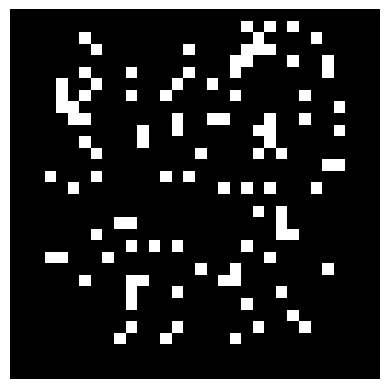

In [13]:
img_tensor = dataset[0]    
img_np = img_tensor.permute(1, 2, 0).numpy()  # Convert (C, H, W) -> (H, W, C)

# Undo normalization: (img * 0.5 + 0.5) brings the values back to [0, 1]
img_np = (img_np * 0.5) + 0.5
plt.imshow(img_np)
plt.axis("off")
plt.show()

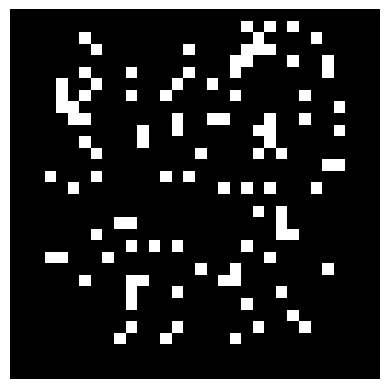

In [15]:
raw_img = decode_record(dataset.records[00])
plt.imshow(raw_img)
plt.axis("off")
plt.show()

# **1) DC-GAN Model**
# **Generator** # 

In [ ]:
class Generator(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.net = nn.Sequential(
            # Input: (N, z_dim, 1, 1)
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            # 4x4 → 8x8
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # 8x8 → 16x16
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 16x16 → 32x32
            nn.ConvTranspose2d(128, 3, 4, 2, 1, bias=False),
            nn.Tanh()   # Output scaled to [-1,1]
        )
    def forward(self, z):
        # z shape: (N, z_dim) → reshape → (N, z_dim, 1, 1)
        return self.net(z)

# **Discriminator** # 

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # 3×32×32 → 64×16×16
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 64×16×16 → 128×8×8
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 128×8×8 → 256×4×4
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),   # ← FIXED (was Batchnorm2d)
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

In [ ]:
G = Generator(z_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
optD = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
optG = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))

In [ ]:
def generate_and_save_images(epoch):
    G.eval()
    with torch.no_grad():
        z = torch.randn(64, z_dim, 1, 1).to(device)
        fake_images = G(z)
        fake_images = fake_images * 0.5 + 0.5  # Denormalize to [0,1]
        save_image(fake_images, f"generated_images/sample_epoch_{epoch}.png", nrow=8)
    G.train()

k = 1  # Generator updates per iteration
p = 5  # Discriminator updates per iteration

# **Training Part(DC-GAN)**

In [ ]:
for epoch in range(1, epochs + 1):
    for i, real_imgs in enumerate(loader):   
        batch_size_curr = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        real = torch.ones(batch_size_curr, 1, device=device)
        fake = torch.zeros(batch_size_curr, 1, device=device)

        # ---- Train D ---- #
        for _ in range(p):
            z = torch.randn(batch_size_curr, z_dim, 1, 1, device=device)
            fake_imgs = G(z)

            real_validity = D(real_imgs)
            d_real_loss = criterion(real_validity, real)

            fake_validity = D(fake_imgs.detach())
            d_fake_loss = criterion(fake_validity, fake)

            d_loss = d_real_loss + d_fake_loss

            optD.zero_grad()
            d_loss.backward()
            optD.step()

        # ---- Train G ---- #
        for _ in range(k):
            z = torch.randn(batch_size_curr, z_dim, 1, 1, device=device)
            fake_imgs = G(z)
            validity = D(fake_imgs)
            g_loss = criterion(validity, real)
            optG.zero_grad()
            g_loss.backward()
            optG.step()
        if i % 200 == 0:
            print(f"[Epoch {epoch}/{epochs}] [Batch {i}/{len(loader)}] "
                  f"D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")
    # Save sample images
    G.eval()
    with torch.no_grad():
        z = torch.randn(64, z_dim, 1, 1, device=device)
        samples = G(z)
        samples = samples * 0.5 + 0.5
        save_image(samples, f"generated_images/epoch_{epoch}.png", nrow=8)
    G.train()

# **2) WGAN-GP Model**

In [18]:
z_dim = 100                # latent size (use your existing z_dim)
image_size = 32
channels = 3
batch_size = 128           # should match your DataLoader
lr = 1e-4                  # recommended for WGAN-GP
beta1 = 0.0
beta2 = 0.9
n_critic = 10               # D updates per G update
gp_lambda = 10.0           # gradient penalty weight
epochs = 56
sample_dir = "wgan_gp_samples"
ckpt_dir = "wgan_gp_checkpoints"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
# Create output folder
os.makedirs("generated_images", exist_ok=True)
os.makedirs(sample_dir, exist_ok=True)
os.makedirs(ckpt_dir, exist_ok=True)

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

cuda


# **Generator** # 

In [24]:
# class ResBlockUp(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super().__init__()
#         self.bn1 = nn.BatchNorm2d(in_channels)
#         self.bn2 = nn.BatchNorm2d(out_channels)
#         self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
#         self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
#         self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
#         self.shortcut = nn.Conv2d(in_channels, out_channels, 1)

#     def forward(self, x):
#         shortcut = self.upsample(x)
#         shortcut = self.shortcut(shortcut)
#         x = self.bn1(x)
#         x = F.relu(x)
#         x = self.upsample(x)
#         x = self.conv1(x)
#         x = self.bn2(x)
#         x = F.relu(x)
#         x = self.conv2(x)
#         return x + shortcut

In [25]:
# class ResNetGenerator(nn.Module):
#     def __init__(self, z_dim=100, channels=3):
#         super().__init__()
#         self.fc = nn.Linear(z_dim, 256 * 4 * 4)
#         self.res1 = ResBlockUp(256, 256)   # 4 → 8
#         self.res2 = ResBlockUp(256, 128)   # 8 → 16
#         self.res3 = ResBlockUp(128, 64)    # 16 → 32
#         self.bn = nn.BatchNorm2d(64)
#         self.conv_img = nn.Conv2d(64, channels, 3, padding=1)

#     def forward(self, z):
#         # z shape: (batch_size, z_dim)
#         out = self.fc(z)
#         out = out.view(-1, 256, 4, 4)
#         out = self.res1(out)
#         out = self.res2(out)
#         out = self.res3(out)
#         out = self.bn(out)
#         out = F.relu(out)
#         out = self.conv_img(out)
#         out = torch.tanh(out)
#         return out

In [19]:
class Generator(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.net = nn.Sequential(
            # Input: (N, z_dim, 1, 1)
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=False),  # -> 4x4
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),    # -> 8x8
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),    # -> 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, channels, 4, 2, 1, bias=False), # -> 32x32
            nn.Tanh()   # Output scaled to [-1,1]
        )
    def forward(self, z):
        # expect z shape (N, z_dim, 1, 1)
        return self.net(z)

# **Discriminator** # 

In [26]:
# def snconv2d(in_channels, out_channels, kernel_size, stride=1, padding=0):
#     return nn.utils.spectral_norm(
#         nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
#     )
# def snlinear(in_features, out_features):
#     return nn.utils.spectral_norm(
#         nn.Linear(in_features, out_features)
#     )
# class CriticSN(nn.Module):
#     def __init__(self, channels=3):
#         super().__init__()
#         self.net = nn.Sequential(
#             # 3x32x32 -> 64x16x16
#             snconv2d(channels, 64, 4, 2, 1),
#             nn.LeakyReLU(0.2, inplace=True),
#             # 64x16x16 -> 128x8x8
#             snconv2d(64, 128, 4, 2, 1),
#             nn.LeakyReLU(0.2, inplace=True),
#             # 128x8x8 → 256x4x4
#             snconv2d(128, 256, 4, 2, 1),
#             nn.LeakyReLU(0.2, inplace=True),
#         )
#         self.fc = snlinear(256 * 4 * 4, 1)
#     def forward(self, x):
#         x = self.net(x)
#         x = x.view(x.size(0), -1)
#         return self.fc(x)

In [21]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # 3×32×32 -> 64×16×16
            nn.Conv2d(channels, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 64×16×16 -> 128×8×8
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(128, affine=True),  # InstanceNorm or LayerNorm often used for critic
            nn.LeakyReLU(0.2, inplace=True),
            # 128×8×8 -> 256×4×4
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(256, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1)  # output a single scalar per image
        )
    def forward(self, x):
        return self.net(x).view(-1)

In [25]:
def gradient_penalty(critic, real, fake, device, lambda_gp=10.0):
    batch_size = real.size(0)
    eps = torch.rand(batch_size, 1, 1, 1, device=device)
    eps = eps.expand_as(real)
    interpolates = eps * real + (1 - eps) * fake
    interpolates.requires_grad_(True)

    d_interpolates = critic(interpolates)

    # For autograd grad, need scalar outputs -> sum the outputs
    grads = autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates, device=device),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]  # grads w.r.t. interpolates
    grads = grads.view(batch_size, -1)
    grad_norm = grads.norm(2, dim=1)  # L2 norm per sample
    gp = ((grad_norm - 1) ** 2).mean() * lambda_gp
    return gp

G = Generator(z_dim).to(device)
D = Discriminator().to(device)
# D = CriticSN().to(device)
# G = ResNetGenerator(z_dim).to(device)
G.apply(weights_init)
D.apply(weights_init)

optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2))

# **Training Part(WGAN-GP)**

In [ ]:
fixed_noise = torch.randn(64, z_dim, 1, 1, device=device)
global_step = 0
for epoch in range(1, epochs + 1):
    for i, real_imgs in enumerate(loader):
        real_imgs = real_imgs.to(device)               # expected shape (B, C, H, W)
        batch_size_curr = real_imgs.size(0)

        # ---------------------
        #  Train Discriminator (critic)
        # ---------------------
        for _ in range(n_critic):
            z = torch.randn(batch_size_curr, z_dim, 1, 1, device=device)
            fake_imgs = G(z).detach()
            # Critic outputs (real and fake)
            d_real = D(real_imgs)       # shape: (B,)
            d_fake = D(fake_imgs)       # shape: (B,)
            # Wasserstein loss for critic
            loss_D = d_fake.mean() - d_real.mean()
            # Gradient penalty
            gp = gradient_penalty(D, real_imgs, fake_imgs, device, lambda_gp=gp_lambda)
            loss_D_total = loss_D + gp

            optimizer_D.zero_grad()
            loss_D_total.backward()
            optimizer_D.step()

        # ---------------------
        #  Train Generator (once)
        # ---------------------
        z = torch.randn(batch_size_curr, z_dim, 1, 1, device=device)
        fake_imgs = G(z)
        g_loss = -D(fake_imgs).mean()   # maximize D(fake) -> minimize -D(fake)
        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()
        global_step += 1
        # logging
        if i % 200 == 0:
            print(f"[Epoch {epoch}/{epochs}] [Batch {i}/{len(loader)}] "
                  f"D: {loss_D.item():.4f} | GP: {gp.item():.4f} | D_total: {loss_D_total.item():.4f} | G: {g_loss.item():.4f}")
    # Save sample images at epoch end
    G.eval()
    with torch.no_grad():
        samples = G(fixed_noise)
        samples = samples * 0.5 + 0.5  # denormalize to [0,1]
        save_image(samples, os.path.join(sample_dir, f"epoch_{epoch:03d}.png"), nrow=8)
    G.train()
    # Optionally save checkpoints
    torch.save({
        'epoch': epoch,
        'G_state_dict': G.state_dict(),
        'D_state_dict': D.state_dict(),
        'optG': optimizer_G.state_dict(),
        'optD': optimizer_D.state_dict(),
    }, os.path.join(ckpt_dir, f"wgan_gp_epoch_{epoch:03d}.pth"))
print("Training finished.")

Corrupt image, skipping.Corrupt image, skipping.

Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.


/usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
[Epoch 1/56] [Batch 0/234] D: -5.3824 | GP: 2.3504 | D_total: -3.0320 | G: 2.2253
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, skipping.
Corrupt image, ski

# **Generating 1000 samples for FID**

In [21]:
out_dir = "generated_1000"
os.makedirs(out_dir, exist_ok=True)
G.eval()
with torch.no_grad():
    for i in range(1000):
        z = torch.randn(1, z_dim, 1, 1, device=device)
        img = G(z)
        img = (img * 0.5 + 0.5)  # back to [0,1]
        vutils.save_image(img, f"{out_dir}/dig-{i:06d}.png")

# **Saving Generated Images**

In [22]:
def save_generated_images(G, z_dim, num_samples=1000, save_dir="generated_images"):
    # --- CLEAN FOLDER ---
    if os.path.exists(save_dir):
        shutil.rmtree(save_dir)     # delete entire folder with old images
    os.makedirs(save_dir, exist_ok=True)
    
    G.eval()
    with torch.no_grad():
        for i in range(num_samples):
            z = torch.randn(1, z_dim, 1, 1).to(device)
            img = G(z)
            img = img * 0.5 + 0.5
            save_image(img, f"{save_dir}/gen_{i:06d}.png")
    print("Saved", num_samples, "images")
# regenerate fresh 1000 images
save_generated_images(G, z_dim, 1000)

Saved 1000 images


In [23]:
print(len([f for f in os.listdir("generated_images") if f.endswith(".png")]))

1000


# **Saving Real Images**

In [24]:
def extract_real_images_from_shards(shard_paths, save_dir="real_images"):
    os.makedirs(save_dir, exist_ok=True)
    idx = 0
    for shard_path in shard_paths:
        print(f"Reading {shard_path} ...")
        with open(shard_path, "r") as f:
            for line in tqdm(f, desc=f"Extracting from " + os.path.basename(shard_path)):
                rec = json.loads(line)
                # choose correct key
                if "img_b64" in rec:
                    b64 = rec["img_b64"]
                elif "img64" in rec:
                    b64 = rec["img64"]
                else:
                    continue  # skip malformed
                img_bytes = base64.b64decode(b64)
                try:
                    img = Image.open(io.BytesIO(img_bytes))
                    # Handle rotation
                    if "exif_rot" in rec and rec["exif_rot"] != 0:
                        img = img.rotate(-rec["exif_rot"], expand=True)
                    img = img.convert("RGB")  # ensure 3-channel
                except Exception as e:
                    # corrupted record
                    continue
                img.save(f"{save_dir}/real_{idx:06d}.png")
                idx += 1
    print(f"\nSaved total {idx} real images to '{save_dir}'")

In [25]:
shard_paths = [
     "/kaggle/input/test-gan-competition/shard_02/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_45/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_09/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_37/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_35/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_15/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_31/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_50/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_20/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_25/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_46/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_39/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_40/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_44/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_33/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_59/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_53/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_54/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_42/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_41/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_04/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_07/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_47/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_18/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_08/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_03/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_43/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_55/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_06/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_12/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_11/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_51/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_13/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_38/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_52/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_17/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_16/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_26/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_48/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_00/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_27/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_24/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_21/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_57/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_28/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_32/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_29/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_10/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_19/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_49/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_14/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_23/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_56/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_30/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_36/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_05/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_58/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_01/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_22/data.jsonl",
    "/kaggle/input/test-gan-competition/shard_34/data.jsonl"       
]
extract_real_images_from_shards(shard_paths)

Reading /kaggle/input/test-gan-competition/shard_02/data.jsonl ...


Extracting from data.jsonl: 1000it [00:00, 3105.01it/s]


Reading /kaggle/input/test-gan-competition/shard_45/data.jsonl ...


Extracting from data.jsonl: 1000it [00:00, 3295.71it/s]


Reading /kaggle/input/test-gan-competition/shard_09/data.jsonl ...


...

Reading /kaggle/input/test-gan-competition/shard_22/data.jsonl ...


Extracting from data.jsonl: 1000it [00:00, 2993.95it/s]


Reading /kaggle/input/test-gan-competition/shard_34/data.jsonl ...


Extracting from data.jsonl: 1000it [00:00, 3064.99it/s]


Saved total 58578 real images to 'real_images'


In [26]:
def load_images_from_folder(folder, transform):
    imgs = []
    failed = []
    for filename in os.listdir(folder):
        if filename.startswith("."):
            continue
        path = os.path.join(folder, filename)
        try:
            img = Image.open(path).convert("RGB")
            imgs.append(transform(img).unsqueeze(0))  # CPU only
        except Exception as e:
            failed.append((filename, str(e)))
    if failed:
        print("Failed images:", failed[:10])
    if len(imgs) == 0:
        raise RuntimeError("No valid images found!")
    return torch.cat(imgs, dim=0)  # Still on CPU
# -------------------------
# Helper: Get activations
# -------------------------
def get_activations(images, model, batch_size=32, device="cuda"):
    model.eval()
    activations = []
    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            batch = images[i:i+batch_size].to(device)
            pred = model(batch)
            activations.append(pred.cpu().numpy())
    return np.concatenate(activations, axis=0)
# -------------------------
# Helper: Compute FID Metric
# -------------------------
def calculate_fid(mu1, sigma1, mu2, sigma2):
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

In [27]:
def calculate_frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    """
    Compute the Frechet Distance between two multivariate Gaussians.
    """
    mu1 = np.atleast_1d(mu1)
    mu2 = np.atleast_1d(mu2)
    sigma1 = np.atleast_2d(sigma1)
    sigma2 = np.atleast_2d(sigma2)
    diff = mu1 - mu2
    # Product might fail due to numerical instability; add epsilon
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if not np.isfinite(covmean).all():
        print("Adding eps to diagonal of covariance matrices for numerical stability")
        offset = np.eye(sigma1.shape[0]) * eps
        covmean, _ = linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset), disp=False)
    # sqrtm sometimes returns complex numbers due to rounding errors
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

In [28]:
def compute_fid_from_folders(real_folder, fake_folder, device):
    transform = transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.ToTensor(),
    ])
    print("Loading images (CPU-only)...")
    real_imgs = load_images_from_folder(real_folder, transform)
    fake_imgs = load_images_from_folder(fake_folder, transform)
    model = models.inception_v3(weights="IMAGENET1K_V1")
    model.fc = torch.nn.Identity()
    model.to(device)
    model.eval()
    
    act_real = get_activations(real_imgs, model, device=device)
    act_fake = get_activations(fake_imgs, model, device=device)
    mu1, sigma1 = act_real.mean(axis=0), np.cov(act_real, rowvar=False)
    mu2, sigma2 = act_fake.mean(axis=0), np.cov(act_fake, rowvar=False)
    fid = calculate_frechet_distance(mu1, sigma1, mu2, sigma2)
    return fid

In [29]:
def create_subset(src_folder, dst_folder, max_images=2000):
    os.makedirs(dst_folder, exist_ok=True)
    files = [f for f in os.listdir(src_folder)
             if os.path.isfile(os.path.join(src_folder, f)) and f.endswith(".png")]
    files = files[:max_images]
    for f in files:
        shutil.copy(os.path.join(src_folder, f), os.path.join(dst_folder, f))
    print(f"Copied {len(files)} images → {dst_folder}")
create_subset("real_images", "real_images_subset", 1000)
shutil.rmtree("generated_images_subset", ignore_errors=True)
create_subset("generated_images", "generated_images_subset", 1000)

Copied 1000 images → real_images_subset
Copied 1000 images → generated_images_subset


In [31]:
print("Real subset:", len(os.listdir("real_images_subset")))
print(os.listdir("real_images_subset")[:10])

print("Generated subset:", len(os.listdir("generated_images_subset")))
print(os.listdir("generated_images_subset")[:10])

Real subset: 6652
['real_020687.png', 'real_051101.png', 'real_019651.png', 'real_032259.png', 'real_006521.png', 'real_041202.png', 'real_039822.png', 'real_009465.png', 'real_036220.png', 'real_006948.png']
Generated subset: 1000
['gen_000786.png', 'gen_000579.png', 'gen_000623.png', 'gen_000171.png', 'gen_000483.png', 'gen_000309.png', 'gen_000392.png', 'gen_000305.png', 'gen_000157.png', 'gen_000120.png']


# **Compute FID Score**

In [32]:
device = torch.device("cpu")
print(device)
fid_score = compute_fid_from_folders(
    "real_images_subset",
    "generated_images_subset",
    device
)
print("Final FID Score:", fid_score)

cpu
Loading images (CPU-only)...


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 210MB/s] 


Final FID Score: 15.436843218206938


In [34]:
m = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)
m.fc = torch.nn.Identity()
m.eval()

preproc = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
])

In [36]:
def extract_feature(img_path):
    img = Image.open(img_path).convert("RGB")
    x = preproc(img).unsqueeze(0)
    with torch.no_grad():
        feat = m(x)
        if isinstance(feat, (list, tuple)):
            feat = feat[0]
    return feat.squeeze().numpy()

In [37]:
generated_folder = "generated_images_subset"
generated_image_paths = sorted(
    [
        os.path.join(generated_folder, f)
        for f in os.listdir(generated_folder)
        if f.lower().endswith(".png")
    ]
)
print("Found generated images:", len(generated_image_paths))
# ---- FIX EXTRA IMAGES BEFORE ASSERTING ----
if len(generated_image_paths) != 1000:
    print("Fixing folder… keeping only 1000 images.")
    # Only keep the first 1000 images
    extra = generated_image_paths[1000:]
    for f in extra:
        os.remove(f)
    # Re-read folder after deletion
    generated_image_paths = sorted(
        [
            os.path.join(generated_folder, f)
            for f in os.listdir(generated_folder)
            if f.lower().endswith(".png")
        ]
    )
    print("After cleanup:", len(generated_image_paths))
# Final check (must pass now)
assert len(generated_image_paths) == 1000, "You must have exactly 1000 images!"

Found generated images: 1000


In [38]:
ids = [f"dig-{i:06d}" for i in range(1000)]
features = []

for i, img_path in enumerate(generated_image_paths):
    feat = extract_feature(img_path)
    features.append(feat)

# **Creating the Submission File**

In [42]:
df = pd.DataFrame(features, columns=[f"f{i}" for i in range(2048)])
df.insert(0, "id", ids)
df.to_csv("submission.csv", index=False)
print("submission.csv created successfully!")

submission.csv created successfully!


# **Downloadable Submission File**

In [43]:
FileLink('submission.csv')

/kaggle/working/submission.csv